# The Tension Between The Rhizome and The Panopticon

 Taking inspiration from systems theory and continental philosophy (specifically Michel Foucault and Gilles Deleuze), here is a brand-new experiment.
This script visualizes the tension between The Panopticon (centralized surveillance, rigid categorization, isolated nodes) and The Rhizome (decentralized, non-hierarchical, organic networks that adapt and reconnect when severed).

Rendering The Disciplinary Panopticon GIF...
Rendering The Nomadic Rhizome GIF...
Displaying Topographical Analysis...



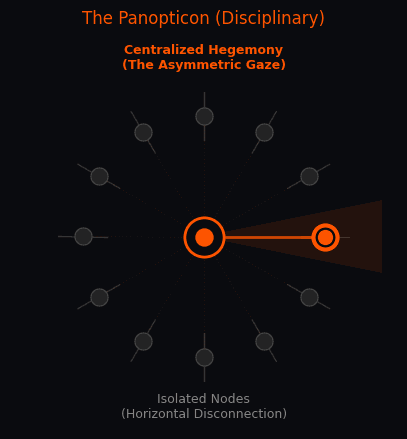
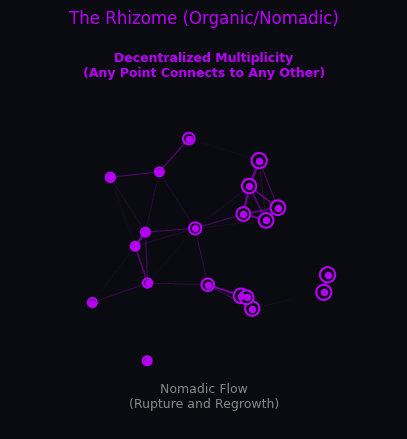

In [1]:
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from PIL import Image
import io
import base64
from IPython.display import display, HTML
import warnings

# Suppress warnings for clean output
warnings.filterwarnings("ignore")

# ---------------------------------------------------------
# Configuration & Theming
# ---------------------------------------------------------
FRAMES = 90
FPS = 30
BG_COLOR = "#0a0b10"  # Deep Void Black
ACCENT_PANOPTICON = "#ff5500"  # Neon Orange (Surveillance / Authority)
ACCENT_RHIZOME = "#bd00ff"     # Proton Purple (Organic / Nomadic)

# Set global Seaborn dark theme
sns.set_theme(style="darkgrid", rc={
    "axes.facecolor": BG_COLOR,
    "figure.facecolor": BG_COLOR,
    "axes.edgecolor": "#111111",
    "grid.color": "#1a1a1a",
    "text.color": "#e0e0e0"
})

def fig_to_image(fig):
    """Converts a matplotlib figure to a PIL Image."""
    buf = io.BytesIO()
    fig.savefig(buf, format='png', bbox_inches='tight', facecolor=fig.get_facecolor(), dpi=100)
    buf.seek(0)
    img = Image.open(buf)
    return img.copy()

# ---------------------------------------------------------
# Visualizer 1: The Panopticon (Disciplinary Gaze)
# ---------------------------------------------------------
def generate_panopticon_gif(filename):
    print("Rendering The Disciplinary Panopticon GIF...")
    frames = []

    num_cells = 12
    radius = 5
    cell_angles = np.linspace(0, 2 * np.pi, num_cells, endpoint=False)

    fig, ax = plt.subplots(figsize=(5, 5))

    for i in range(FRAMES):
        ax.clear()
        progress = i / FRAMES
        scan_angle = progress * 2 * np.pi

        # Central Watchtower
        ax.scatter(0, 0, color=BG_COLOR, edgecolor=ACCENT_PANOPTICON, s=800, linewidth=2, zorder=6)
        ax.scatter(0, 0, color=ACCENT_PANOPTICON, s=150 + 50 * np.sin(progress * np.pi * 8), zorder=6)

        # Draw cells and gaze
        for j, angle in enumerate(cell_angles):
            cx = radius * np.cos(angle)
            cy = radius * np.sin(angle)

            # Distance from the scanning "gaze"
            angle_diff = np.abs((angle - scan_angle + np.pi) % (2 * np.pi) - np.pi)
            is_watched = angle_diff < 0.4

            # Walls of isolation (nodes cannot connect to each other)
            ax.plot([cx*0.8, cx*1.2], [cy*0.8, cy*1.2], color="#333", linewidth=1, zorder=1)

            if is_watched:
                # The Gaze hits the cell
                ax.plot([0, cx], [0, cy], color=ACCENT_PANOPTICON, alpha=0.8, linewidth=2, zorder=2)
                ax.scatter(cx, cy, color=BG_COLOR, edgecolor=ACCENT_PANOPTICON, s=300, linewidth=3, zorder=5)
                ax.scatter(cx, cy, color=ACCENT_PANOPTICON, s=100, zorder=5) # Exposed
            else:
                # Shadow/Isolated state
                ax.plot([0, cx], [0, cy], color=ACCENT_PANOPTICON, alpha=0.1, linewidth=1, linestyle=":", zorder=2)
                ax.scatter(cx, cy, color="#222", edgecolor="#444", s=150, zorder=5)

        # Radar Sweep Effect
        wedge_x = [0, radius * 1.5 * np.cos(scan_angle - 0.2), radius * 1.5 * np.cos(scan_angle + 0.2)]
        wedge_y = [0, radius * 1.5 * np.sin(scan_angle - 0.2), radius * 1.5 * np.sin(scan_angle + 0.2)]
        ax.fill(wedge_x, wedge_y, color=ACCENT_PANOPTICON, alpha=0.1, zorder=1)

        ax.text(0, 7, "Centralized Hegemony\n(The Asymmetric Gaze)", color=ACCENT_PANOPTICON, ha="center", fontsize=9, fontweight="bold")
        ax.text(0, -7.5, "Isolated Nodes\n(Horizontal Disconnection)", color="#888", ha="center", fontsize=9)

        ax.set_ylim(-8, 8)
        ax.set_xlim(-8, 8)
        ax.set_title("The Panopticon (Disciplinary)", color=ACCENT_PANOPTICON, pad=15)
        ax.axis('off')

        frames.append(fig_to_image(fig))

    plt.close(fig)
    frames[0].save(filename, save_all=True, append_images=frames[1:], duration=int(1000/FPS), loop=0)
    return filename

# ---------------------------------------------------------
# Visualizer 2: The Rhizome (Nomadic Multiplicity)
# ---------------------------------------------------------
def generate_rhizome_gif(filename):
    print("Rendering The Nomadic Rhizome GIF...")
    frames = []

    fig, ax = plt.subplots(figsize=(5, 5))

    num_nodes = 20
    np.random.seed(42) # For predictable chaotic loops

    # Generate random parameters for Lissajous-style looping movement
    A = np.random.uniform(2, 6, num_nodes)
    B = np.random.uniform(2, 6, num_nodes)
    freq_x = np.random.choice([1, 2], num_nodes)
    freq_y = np.random.choice([1, 2], num_nodes)
    phase_x = np.random.uniform(0, 2*np.pi, num_nodes)
    phase_y = np.random.uniform(0, 2*np.pi, num_nodes)

    for i in range(FRAMES):
        ax.clear()
        t = i / FRAMES

        # Calculate positions
        nx = A * np.sin(2 * np.pi * freq_x * t + phase_x)
        ny = B * np.sin(2 * np.pi * freq_y * t + phase_y)

        # Draw Dynamic Mycelial Connections
        for j in range(num_nodes):
            for k in range(j + 1, num_nodes):
                dist = np.sqrt((nx[j] - nx[k])**2 + (ny[j] - ny[k])**2)
                # Connect if close enough (emergence of networks)
                if dist < 4.0:
                    intensity = 1.0 - (dist / 4.0)
                    ax.plot([nx[j], nx[k]], [ny[j], ny[k]],
                            color=ACCENT_RHIZOME, alpha=intensity * 0.8, linewidth=intensity * 2)

        # Node visualization (breathing effect)
        node_sizes = 80 + 40 * np.sin(2 * np.pi * t * 3 + phase_x)
        ax.scatter(nx, ny, color=BG_COLOR, edgecolor=ACCENT_RHIZOME, s=node_sizes, linewidth=1.5, zorder=5)
        ax.scatter(nx, ny, color=ACCENT_RHIZOME, s=20, alpha=0.9, zorder=5)

        # A subtle background field representing the "Plane of Immanence"
        field_radius = 5 + 0.5 * np.sin(t * 2 * np.pi)
        field = plt.Circle((0, 0), field_radius, color=ACCENT_RHIZOME, alpha=0.03)
        ax.add_patch(field)

        ax.text(0, 7.5, "Decentralized Multiplicity\n(Any Point Connects to Any Other)", color=ACCENT_RHIZOME, ha="center", fontsize=9, fontweight="bold")
        ax.text(0, -8, "Nomadic Flow\n(Rupture and Regrowth)", color="#888", ha="center", fontsize=9)

        ax.set_ylim(-9, 9)
        ax.set_xlim(-9, 9)
        ax.set_title("The Rhizome (Organic/Nomadic)", color=ACCENT_RHIZOME, pad=15)
        ax.axis('off')

        frames.append(fig_to_image(fig))

    plt.close(fig)
    frames[0].save(filename, save_all=True, append_images=frames[1:], duration=int(1000/FPS), loop=0)
    return filename

# ---------------------------------------------------------
# Execution & HTML Display
# ---------------------------------------------------------
file_panopticon = generate_panopticon_gif('panopticon.gif')
file_rhizome = generate_rhizome_gif('rhizome.gif')

def image_to_base64(filepath):
    with open(filepath, "rb") as image_file:
        return base64.b64encode(image_file.read()).decode('utf-8')

b64_panopticon = image_to_base64(file_panopticon)
b64_rhizome = image_to_base64(file_rhizome)

print("Displaying Topographical Analysis...")

html_code = f"""
<div style="display: flex; gap: 30px; flex-wrap: wrap; justify-content: center; font-family: 'Courier New', monospace; color: white; background-color: #0a0b10; padding: 25px; border-radius: 12px; border: 1px solid #222;">

    <!-- Left Column: The Panopticon -->
    <div style="text-align: center; max-width: 420px;">
        <h3 style="color: #ff5500; font-size: 16px; margin-bottom: 5px; text-transform: uppercase; letter-spacing: 1px;">Architecture 1: The Panopticon<br><span style="font-size: 11px; color: #888;">(Disciplinary Isolation)</span></h3>
        <p style="font-size: 12px; color: #aaa; margin-bottom: 15px; text-align: justify; line-height: 1.4;">
            Modeled after Foucault's analysis of power. A centralized authority asserts control not through constant violence, but through the <b>asymmetric gaze</b>. Nodes (subjects) are walled off from one another, preventing horizontal solidarity. They must internalize the surveillance, assuming they are always being watched. The system is orderly, but utterly static and psychologically sterile.
        </p>
        <img src="data:image/gif;base64,{b64_panopticon}" style="border: 1px solid #441100; border-radius: 8px; box-shadow: 0 0 20px rgba(255,85,0,0.2); width: 100%;">
    </div>

    <!-- Right Column: The Rhizome -->
    <div style="text-align: center; max-width: 420px;">
        <h3 style="color: #bd00ff; font-size: 16px; margin-bottom: 5px; text-transform: uppercase; letter-spacing: 1px;">Architecture 2: The Rhizome<br><span style="font-size: 11px; color: #888;">(Nomadic Multiplicity)</span></h3>
        <p style="font-size: 12px; color: #aaa; margin-bottom: 15px; text-align: justify; line-height: 1.4;">
            Rooted in Deleuze and Guattari's topology. The network has no center, no beginning, and no end. Any node can connect to any other node based on proximity and shared affinity. If a connection is severed, the network organically reroutes around the rupture. It is anti-genealogical, highly resilient, and operates on a continuous <b>plane of immanence</b>.
        </p>
        <img src="data:image/gif;base64,{b64_rhizome}" style="border: 1px solid #220033; border-radius: 8px; box-shadow: 0 0 20px rgba(189,0,255,0.2); width: 100%;">
    </div>

</div>
"""

display(HTML(html_code))

What this visualizes:
The Left (Panopticon): Visualizes structural isolation. The central tower acts like a radar sweep. When the "gaze" falls on an outer node, it illuminates, demonstrating how centralized power relies on visibility of the edges while keeping the edges blind to each other.
The Right (Rhizome): Uses mathematical Lissajous curves to simulate organic, mycelium-like movement. The nodes drift autonomously, and as they get close to one another, connections spark and solidify, creating a highly resilient, constantly shifting decentralized mesh.